(01-03-williams-ddm)=

# Williams en het dividend discount model

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1938–1959.

**Wat we al weten.** Uit [](#01-02-bachelier) komt een statistische beschrijving
van koersen: prijsveranderingen zijn vrijwel onvoorspelbaar en hun spreiding
groeit met $\sqrt{t}$. Dat is een uitspraak over *veranderingen*, niet over
*niveaus*. Bachelier, Cowles en Kendall konden zeggen dat je de koers van morgen
niet uit die van vandaag kunt afleiden; niemand van hen kon zeggen waarom de
koers van vandaag is wat hij is. De barst die het tijdvak achterliet is dus een
gat: er was een theorie van de ruis en geen theorie van het niveau.

**Welke vraag staat open.** Wat is een aandeel waard — welke grootheid maakt van
een koers iets anders dan een getal waar mensen het toevallig over eens zijn?
```

## Overzicht

In 1938 publiceerde John Burr Williams *The Theory of Investment Value*
{cite}`Williams1938`, een proefschrift dat hij bij Schumpeter in Harvard
verdedigde en waarin één zin staat die het vak van waardering heeft
vastgelegd: de waarde van een investering is de contante waarde van de
uitkeringen die zij ooit zal doen. Voor een aandeel zijn die uitkeringen de
dividenden. Williams schreef dat op in een tijd waarin de gangbare praktijk
was om een aandeel te waarderen door de winst met een gewoontegetal te
vermenigvuldigen; hij verving het gewoontegetal door een som en dwong daarmee
iedereen die het oneens was om te zeggen *waarover* precies.

Deze lecture bouwt die som op vanaf de definitie van rendement, laat zien
onder welke voorwaarde hij precies geldt, en werkt hem uit tot de formule
waarmee hij de praktijk in ging: het Gordon-groeimodel
{cite}`GordonShapiro1956,Gordon1959`, $p = d_1/(r-g)$. Het werk definieert het
tijdvak omdat het de eerste keer is dat een prijs uit een model volgt en niet
uit een gewoonte. Tegelijk zal blijken dat het model een merkwaardige
epistemische status heeft: als je $r$ vrij laat, is de formule geen theorie maar
een boekhoudkundige identiteit — hij kán niet fout zijn, hij kan alleen leeg
zijn. Dat is precies de spanning waarmee de rest van deze reeks zich
bezighoudt.

Aan het eind repliceren we de enige toets die de identiteit toelaat. De
prijs-dividend-ratio beweegt enorm — van 10 tot 86 in de Amerikaanse
geschiedenis. Als $r$ constant is, moet die beweging voorspellen dat de
dividenden hard gaan groeien. We regresseren op Shillers data
(`hap.data.shiller()`) de gerealiseerde tienjaarsgroei van dividenden en het
gerealiseerde tienjaarsrendement op de prijs-dividend-ratio, en kijken welke van
de twee reageert.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Een aandeel is een stukje papier. Het geeft geen nut, het gaat niet stuk, en je
kunt er niet in wonen. Het enige wat het ooit voor u doet, is af en toe geld
uitkeren. Alles wat een aandeel waard kan zijn, moet dus uit die uitkeringen
komen — óf uit de prijs waarvoor u het later verkoopt. Maar wie het later van u
koopt, staat voor precies dezelfde vraag, en die kan ook alleen maar op
uitkeringen en op een nóg latere verkoopprijs rekenen. Blijf die redenering
doorzetten en de verkoopprijs schuift steeds verder de toekomst in, tot hij
verdwijnt. Wat overblijft is de stroom dividenden.

Dat is de hele gedachte van Williams, en de kracht ervan zit in wat hij
*uitsluit*. Hij sluit uit dat een aandeel waarde ontleent aan het feit dat
anderen het willen hebben. Hij sluit uit dat een koers hoog is omdat hij de
laatste jaren hoog was. In zijn eigen beeld: een investeerder koopt geen
koersen, hij koopt een boomgaard, en een boomgaard is de appels waard die
eraan komen — niet meer, en niet minder, ongeacht wat de buurman voor zijn
boomgaard heeft betaald.

Twee dingen zijn nu nodig om van die gedachte een getal te maken. Ten eerste een
verwachting over de dividenden. Ten tweede een tarief waartegen u een euro
volgend jaar omrekent naar een euro vandaag. Williams noemde dat tarief de
*interest rate*; de moderne naam is *discontovoet*. Over de dividenden schreef
hij honderden bladzijden — hoofdstukken vol algebra over groeiende, dalende en
eindige dividendstromen, en tabellen die hij met de hand had uitgerekend. Over
de discontovoet schreef hij vrijwel niets. Hij nam hem als gegeven.

Dat is geen slordigheid maar de stand van de wetenschap in 1938. Er bestond nog
geen theorie die zei welk tarief bij welk risico hoort; het CAPM is dan nog
zesentwintig jaar weg, en de gedachte dat de vereiste vergoeding uit een
evenwicht volgt — dat er een *prijs van risico* is die voor alle activa gelijk is
— moest nog worden bedacht. Williams zag het gat en liep eromheen. Zijn formule
is daardoor waar zonder iets te zeggen: geef mij de dividendverwachtingen en de
discontovoet, en ik geef u de prijs. Geef mij de prijs en de
dividendverwachtingen, en ik geef u de discontovoet. Er is geen derde
vergelijking die de zaak vastpint.

```{note}
Williams verkocht in 1938 ongeveer geen exemplaren. Het boek werd herontdekt in
de jaren vijftig, toen Gordon en Shapiro de oneindige som tot één breuk
samentrokken en er iets van maakten dat een analist in twee minuten kon
gebruiken {cite}`GordonShapiro1956`. Dat is een terugkerend patroon in dit vak:
een idee wordt pas gebruikt zodra iemand het tot een formule met drie symbolen
heeft ingedikt, en wordt dan ook op plaatsen gebruikt waar het niet hoort.
```

## Toy-voorbeeld: drie jaar dividenden, met de hand verdisconteerd

Neem een bedrijf dat zojuist een dividend van $d_0 = 1{,}00$ per aandeel heeft
uitgekeerd. Het dividend groeit de komende drie jaar met 10% per jaar, en daarna
voor altijd met 5% per jaar. De discontovoet is $r = 10\%$.

De eerste drie dividenden zijn dan

$$
d_1 = 1{,}10, \qquad d_2 = 1{,}21, \qquad d_3 = 1{,}331 .
$$

Verdisconteren gaat per jaar met een factor $1{,}10$. Omdat de groeivoet in deze
eerste fase *toevallig gelijk is aan de discontovoet*, is elke term precies
gelijk aan één:

$$
\frac{1{,}10}{1{,}10} = 1{,}00, \qquad
\frac{1{,}21}{1{,}21} = 1{,}00, \qquad
\frac{1{,}331}{1{,}331} = 1{,}00 .
$$

De eerste drie dividenden zijn samen dus $3{,}00$ waard. Wat op $t=3$ nog
resteert, is een dividendstroom die met 5% groeit vanaf $d_4 = 1{,}331 \times
1{,}05 = 1{,}39755$. De contante waarde daarvan, gezien vanaf jaar 3, is
$d_4/(r-g) = 1{,}39755/0{,}05 = 27{,}951$. Terugrekenen naar vandaag met
$1{,}10^3 = 1{,}331$ geeft $27{,}951/1{,}331 = 21{,}00$ — exact, want
$1{,}331 \times 21 = 27{,}951$.

De prijs vandaag is daarmee

$$
p_0 = 3{,}00 + 21{,}00 = 24{,}00 ,
$$

en de prijs-dividend-ratio is $\mathrm{PD}_0 = 24{,}00/1{,}00 = 24$.

Let op de verdeling. Van de $24{,}00$ komt $3{,}00$ uit de dividenden van de
komende drie jaar en $21{,}00$ — 87,5% — uit alles daarna. Dat is geen artefact
van dit voorbeeld: bij een discontovoet van 10% en een groeivoet van 5% ligt
het zwaartepunt van een aandelenwaardering standaard twintig tot dertig jaar in
de toekomst. Elke waardering van een aandeel is dus in overwegende mate een
uitspraak over een periode waarover niemand iets weet. Onthoud dat; het is de
reden dat de simulatie verderop eruitziet zoals hij eruitziet.

In [2]:
d0, r, g_hoog, g_lang, n = 1.00, 0.10, 0.10, 0.05, 3

years = np.arange(1, n + 1)
dividends = d0 * (1 + g_hoog) ** years
discounted = dividends / (1 + r) ** years

d_next = dividends[-1] * (1 + g_lang)
terminal = d_next / (r - g_lang)
terminal_pv = terminal / (1 + r) ** n
price = discounted.sum() + terminal_pv

toy = pd.DataFrame(
    {
        "jaar": list(years) + ["3 (eindwaarde)", "totaal"],
        "dividend": list(dividends.round(4)) + [np.nan, np.nan],
        "contante waarde": list(discounted.round(4)) + [terminal_pv, price],
    }
).set_index("jaar").round(4)

print(f"eindwaarde op t=3 : {terminal:.3f}   (met de hand: 27.951)")
print(f"prijs p_0         : {price:.4f}   (met de hand: 24.0000)")
print(f"aandeel eindwaarde: {terminal_pv / price:.4%}  (met de hand: 87.5000%)")
toy

eindwaarde op t=3 : 27.951   (met de hand: 27.951)
prijs p_0         : 24.0000   (met de hand: 24.0000)
aandeel eindwaarde: 87.5000%  (met de hand: 87.5000%)


,dividend,contante waarde
jaar,,
1,1.100,1.0
2,1.210,1.0
3,1.331,1.0
3 (eindwaarde),NaN,21.0
totaal,NaN,24.0


De code geeft $27{,}951$, $24{,}0000$ en $87{,}5000\%$ — dezelfde getallen als de
handberekening, tot op de laatste decimaal. Vanaf hier mag u aannemen dat de
code doet wat de wiskunde zegt.

### De gevoeligheid die alles bepaalt

Laat de eerste fase weg en neem het pure Gordon-geval: $d_0 = 1{,}00$, groei
$g = 5\%$ voor altijd, $r = 10\%$. Dan is
$p = d_0(1+g)/(r-g) = 1{,}05/0{,}05 = 21{,}00$, dus $\mathrm{PD} = 21$.

Verander nu één procentpunt. Bij $r = 9\%$ wordt het $1{,}05/0{,}04 = 26{,}25$,
een stijging van 25%. Bij $g = 6\%$ wordt het $1{,}06/0{,}04 = 26{,}50$, een
stijging van 26,2%. Bij $r = 11\%$ wordt het $1{,}05/0{,}06 = 17{,}50$, een
daling van 16,7%.

De prijs hangt niet af van $r$ en $g$ afzonderlijk maar vrijwel volledig van hun
*verschil*, en dat verschil is klein: 5 procentpunt. Een fout van één procentpunt
in een van beide is een fout van twintig procent in dat verschil, en de prijs is
er ongeveer omgekeerd evenredig mee. Waarderen met dit model is delen door een
klein getal dat u niet kent.

In [3]:
def gordon(d0, r, g):
    """Gordon growth price of a claim on a dividend growing at g forever."""
    return d0 * (1 + g) / (r - g)

grid = pd.DataFrame(
    {g: [gordon(1.00, r, g) for r in (0.09, 0.10, 0.11)] for g in (0.04, 0.05, 0.06)},
    index=pd.Index([0.09, 0.10, 0.11], name="discontovoet r"),
).rename_axis("groeivoet g", axis=1).round(2)

print(f"basisgeval r=10%, g=5% : PD = {gordon(1.00, 0.10, 0.05):.2f}   (met de hand: 21.00)")
print(f"r=9%                   : PD = {gordon(1.00, 0.09, 0.05):.2f}   (+25.0%)")
print(f"g=6%                   : PD = {gordon(1.00, 0.10, 0.06):.2f}   (+26.2%)")
grid

basisgeval r=10%, g=5% : PD = 21.00   (met de hand: 21.00)
r=9%                   : PD = 26.25   (+25.0%)
g=6%                   : PD = 26.50   (+26.2%)


groeivoet g,0.04,0.05,0.06
discontovoet r,,,
0.09,20.80,26.25,35.33
0.10,17.33,21.00,26.50
0.11,14.86,17.50,21.20


## Theorie

### Opzet en notatie

Er is één aandeel dat op elk tijdstip $t$ een dividend $d_t$ uitkeert en waarvan
de prijs $p_t$ *ex dividend* is: wie op $t$ voor $p_t$ koopt, krijgt $d_{t+1}$ en
niet $d_t$. Het bruto rendement over de periode van $t$ naar $t+1$ is dan

```{math}
:label: eq-williams-ddm-rendement
R_{t+1} = \frac{p_{t+1} + d_{t+1}}{p_t}.
```

Dit is een definitie, geen aanname: het is gewoon hoe u uw rendement uitrekent.
Alles wat volgt komt hieruit plus één aanname over verwachtingen.

De aanname is die van Williams: er bestaat een getal $r$ zodanig dat voor elke
periode $\E_t[R_{t+1}] = 1 + r$. Dat wil zeggen dat het verwachte rendement
constant is — niet dat het gerealiseerde rendement constant is. In de notatie
van de [inleiding](#index) schrijven we $R = 1+r$ en houden we $r$ voorlopig
niet-tijdvariërend. Later in de reeks laten we die aanname vallen; op dit moment
in de geschiedenis was er nog niets om hem mee te vervangen.

### Van de definitie van rendement naar de contante waarde

*Waarom zou dit waar zijn?* Neem de definitie van rendement en lees hem
achterstevoren. Rechts staat wat u morgen krijgt: een dividend en een prijs.
Links staat wat u vandaag betaalt. Als u weet wat het verwachte rendement is —
dat is de aanname — dan is de prijs van vandaag niets anders dan de verwachte
opbrengst van morgen, gedeeld door dat rendement. Herhaal dat argument op de
prijs van morgen, en op die van overmorgen, en de prijzen verdwijnen één voor
één uit de vergelijking. Wat overblijft zijn de dividenden. Dat is de hele
afleiding; de rest is bijhouden welke index waar staat.

Neem verwachtingen op $t$ in [](#eq-williams-ddm-rendement) en gebruik
$\E_t[R_{t+1}] = 1+r$:

$$
p_t = \frac{\E_t\!\left[d_{t+1} + p_{t+1}\right]}{1+r}.
$$

Deze vergelijking geldt op elk tijdstip, dus ook op $t+1$:
$p_{t+1} = \E_{t+1}[d_{t+2} + p_{t+2}]/(1+r)$. Substitueer dat in de vorige
vergelijking en gebruik de wet van iteratieve verwachtingen
($\E_t[\E_{t+1}[\cdot]] = \E_t[\cdot]$; wat u vandaag verwacht morgen te
verwachten, verwacht u vandaag):

$$
p_t = \frac{\E_t[d_{t+1}]}{1+r} + \frac{\E_t[d_{t+2}]}{(1+r)^2}
      + \frac{\E_t[p_{t+2}]}{(1+r)^2}.
$$

Nog $K-2$ keer herhalen geeft de eindige versie van de identiteit:

```{math}
:label: eq-williams-ddm-eindig
p_t = \sum_{j=1}^{K} \frac{\E_t\!\left[d_{t+j}\right]}{(1+r)^{j}}
      + \frac{\E_t\!\left[p_{t+K}\right]}{(1+r)^{K}} .
```

Tot hier is er geen enkele aanname bij gekomen. [](#eq-williams-ddm-eindig) is
waar voor elke $K$, en zegt niets meer dan dat een prijs de contante waarde is
van de dividenden tot $K$ plus de contante waarde van wat er dan nog staat.

### De transversaliteitsvoorwaarde en de bel die u weglaat

*Waarom zou dit waar zijn?* Om van de eindige som de oneindige som te maken,
moet de laatste term verdwijnen. Dat is geen wiskundige technicaliteit maar de
economische kern van het model. De term $\E_t[p_{t+K}]/(1+r)^K$ is de waarde die
u vandaag hecht aan de mogelijkheid het aandeel over $K$ jaar door te verkopen,
en de eis dat hij naar nul gaat, is de eis dat een aandeel niets waard is om het
doorverkopen zelf. Laat u die eis vallen, dan staat u toe dat een prijs hoog is
uitsluitend omdat men verwacht dat hij morgen hoger is.

:::{prf:theorem} Dividend discount model
:label: thm-williams-ddm-ddm

Als $\E_t[R_{t+1}] = 1+r$ voor alle $t$ met $r > 0$, en als de
transversaliteitsvoorwaarde

```{math}
:label: eq-williams-ddm-transversaliteit
\lim_{K \to \infty} \frac{\E_t\!\left[p_{t+K}\right]}{(1+r)^{K}} = 0
```

geldt, dan is

```{math}
:label: eq-williams-ddm-ddm
p_t = \sum_{j=1}^{\infty} \frac{\E_t\!\left[d_{t+j}\right]}{(1+r)^{j}} .
```
:::

:::{prf:proof}
Neem in [](#eq-williams-ddm-eindig) de limiet $K \to \infty$. De partiële sommen
zijn niet-dalend zodra dividenden niet-negatief zijn, dus de reeks convergeert
of divergeert naar $+\infty$; de restterm gaat naar nul volgens
[](#eq-williams-ddm-transversaliteit). Convergentie van het geheel volgt uit de
eindigheid van $p_t$ zelf. $\square$
:::

Wat gebeurt er als [](#eq-williams-ddm-transversaliteit) niet geldt? Noem de
oplossing uit [](#eq-williams-ddm-ddm) de *fundamentele waarde* $p^{f}_t$, en
bekijk $p_t = p^{f}_t + b_t$ met

$$
\E_t[b_{t+1}] = (1+r)\, b_t .
$$

Zo'n $b_t$ heet een *rationele bel* (rational bubble: een component van de prijs
die geen enkele uitkering vertegenwoordigt maar toch precies het vereiste
rendement oplevert). Reken na dat $p_t = p^f_t + b_t$ opnieuw voldoet aan
$p_t = \E_t[d_{t+1}+p_{t+1}]/(1+r)$: de bel groeit in verwachting met exact
$1+r$ en betaalt daarmee zijn eigen rendement. Er is niets *irrationeels* aan;
iedereen verdient wat hij eist. Alleen is er geen dividend dat het draagt, en
neemt het aandeel van de bel in de prijs onbegrensd toe.

Williams schreef de bel weg door hem niet te noemen. Dat is verdedigbaar — met
$b_t \neq 0$ is de prijs onbepaald en kun je niets rekenen — maar het is een
keuze, en het is precies de keuze waar het vak veertig jaar later over uit
elkaar valt. Wie in 1999 zei dat internetaandelen te duur waren, zei dat er een
$b_t$ in zat. Wie zei dat ze correct geprijsd waren, zei dat $\E_t[d_{t+j}]$
enorm was. De data kan die twee niet scheiden zonder verdere aannames; zie
[](#03-15-shiller-excess-volatility).

```{warning}
De transversaliteitsvoorwaarde is een *aanname*, geen stelling. In de reeks
hierna wordt hij bijna overal stilzwijgend opgelegd, ook in modellen die
verderop kritisch tegenover Williams staan. Elke keer dat u een variantiegrens
of een decompositie van de prijs-dividend-ratio ziet, is
[](#eq-williams-ddm-transversaliteit) ergens ingezet.
```

### Het Gordon-groeimodel

*Waarom zou dit waar zijn?* De oneindige som in [](#eq-williams-ddm-ddm) is
onbruikbaar zolang u voor elk toekomstig jaar een apart getal moet verzinnen.
Gordon en Shapiro vervingen die getallen door één parameter: neem aan dat het
dividend in verwachting elk jaar met hetzelfde percentage groeit. Dan is de som
een meetkundige reeks, en meetkundige reeksen tellen op tot een breuk.

:::{prf:proposition} Gordon-Shapiro
:label: prf-williams-ddm-gordon

Als $\E_t[d_{t+j}] = d_t (1+g)^{j}$ met $g < r$, dan geldt

```{math}
:label: eq-williams-ddm-gordon
p_t = \frac{d_t (1+g)}{r - g} = \frac{\E_t[d_{t+1}]}{r-g},
\qquad\text{equivalent}\qquad
r = \frac{\E_t[d_{t+1}]}{p_t} + g .
```
:::

:::{prf:proof}
Vul de groeiaanname in [](#eq-williams-ddm-ddm) in:

$$
p_t = \sum_{j=1}^{\infty} \frac{d_t (1+g)^j}{(1+r)^j}
    = d_t \sum_{j=1}^{\infty} q^{j}, \qquad q \equiv \frac{1+g}{1+r} .
$$

Voor $g<r$ is $0 < q < 1$ en is $\sum_{j\ge1} q^j = q/(1-q)$. Invullen:

$$
p_t = d_t \frac{(1+g)/(1+r)}{1 - (1+g)/(1+r)}
    = d_t \frac{1+g}{(1+r)-(1+g)} = \frac{d_t(1+g)}{r-g}. \qquad \square
$$
:::

De tweede schrijfwijze in [](#eq-williams-ddm-gordon) is de nuttigste van de
twee en wordt in dit vak overal gebruikt: het verwachte rendement is het
dividendrendement plus de dividendgroei. Als u weet wat u vandaag aan dividend
krijgt en hoe hard dat groeit, weet u wat u verdient — zolang de
prijs-dividend-ratio niet verandert.

De voorwaarde $g < r$ is geen randgeval maar de kern. Groeit een dividend voor
altijd sneller dan uw discontovoet, dan is de contante waarde oneindig. Dat is
geen wiskundig ongemak maar een economische uitspraak: er bestaat geen bedrijf
dat voor altijd sneller groeit dan de economie waarin het opereert, en dus is
$g$ op lange termijn begrensd door de groei van het bruto binnenlands product.
Elke waardering waarin $g$ dicht bij $r$ ligt, is een waardering waarin die
begrenzing wordt genegeerd.

```{note}
$g$ is de groei van het dividend *per aandeel*, niet die van de winst of van de
omzet. Bedrijven die aandelen uitgeven, laten de winst sneller groeien dan het
dividend per aandeel; bedrijven die aandelen inkopen, andersom. Sinds ongeveer
1985 keren Amerikaanse bedrijven een groeiend deel van hun uitkeringen uit via
inkoop in plaats van dividend, waardoor de gemeten $d_t$ te laag en de gemeten
$g$ te hoog is. Bij elke replicatie op moderne data is dat een reële zorg.
```

### PVGO: wat groei toevoegt en wat het kost

*Waarom zou dit waar zijn?* Een bedrijf dat al zijn winst uitkeert, groeit niet
en is een eeuwigdurende obligatie waard: $e_1/r$. Wil het groeien, dan moet het
winst inhouden, en die ingehouden euro's zijn euro's die u niet krijgt. Groei is
dus niet gratis; hij is de moeite waard precies wanneer het bedrijf op de
ingehouden euro meer verdient dan u er zelf mee zou doen.

Schrijf $e_{t+1}$ voor de winst per aandeel, $b$ voor het ingehouden deel
(*retention ratio*) en $\mathrm{ROE}$ voor het rendement op nieuw geïnvesteerd
vermogen. Dan is $d_{t+1} = (1-b)\,e_{t+1}$ en groeit de winst met
$g = b \cdot \mathrm{ROE}$. Invullen in [](#eq-williams-ddm-gordon):

```{math}
:label: eq-williams-ddm-pvgo
p_t = \frac{(1-b)\,e_{t+1}}{r - b\cdot\mathrm{ROE}}
    = \underbrace{\frac{e_{t+1}}{r}}_{\text{geen groei}} + \mathrm{PVGO},
```

waarbij $\mathrm{PVGO}$ (*present value of growth opportunities*: de contante
waarde van de groeimogelijkheden) het verschil is. Enig rekenwerk geeft

$$
\mathrm{PVGO} = \frac{b\,e_{t+1}}{r}\cdot\frac{\mathrm{ROE}-r}{r - b\cdot\mathrm{ROE}} ,
$$

en daarmee het beslissende inzicht: het teken van $\mathrm{PVGO}$ is het teken
van $\mathrm{ROE} - r$. Een bedrijf dat winst inhoudt om te investeren tegen een
rendement onder de discontovoet *vernietigt* waarde door te groeien, hoe hard
het ook groeit. Dat is de reden dat "groeiaandeel" geen synoniem is van "goede
belegging" — een onderscheid dat in [](#03-16-vroege-anomalieen) empirisch
terugkomt.

In [4]:
e1, r_pvgo, roe = 3.00, 0.10, 0.15
b = 1 / 3

g_impl = b * roe
d1 = (1 - b) * e1
p_pvgo = d1 / (r_pvgo - g_impl)
no_growth = e1 / r_pvgo

print(f"g = b * ROE      : {g_impl:.4f}")
print(f"d_1 = (1-b) e_1  : {d1:.4f}")
print(f"prijs            : {p_pvgo:.2f}")
print(f"waarde zonder groei e_1/r : {no_growth:.2f}")
print(f"PVGO             : {p_pvgo - no_growth:.2f}")
print(f"PVGO bij ROE = 8% (< r)   : "
      f"{(1 - b) * e1 / (r_pvgo - b * 0.08) - no_growth:.2f}")

g = b * ROE      : 0.0500
d_1 = (1-b) e_1  : 2.0000
prijs            : 40.00
waarde zonder groei e_1/r : 30.00
PVGO             : 10.00
PVGO bij ROE = 8% (< r)   : -2.73


Met $\mathrm{ROE} = 15\%$ boven een discontovoet van 10% is $\mathrm{PVGO}$
gelijk aan $10$ op een prijs van $40$: een kwart van de waarde zit in wat het
bedrijf nog gaat doen. Bij $\mathrm{ROE} = 8\%$ wordt $\mathrm{PVGO}$ negatief —
hetzelfde bedrijf, dezelfde groei-inspanning, en de aandeelhouder is er slechter
aan toe.

### Wat de identiteit wél toetsbaar maakt

Deel [](#eq-williams-ddm-ddm) door $d_t$:

```{math}
:label: eq-williams-ddm-pd
\mathrm{PD}_t = \frac{p_t}{d_t}
  = \sum_{j=1}^{\infty} \frac{\E_t\!\left[d_{t+j}/d_t\right]}{(1+r)^{j}} .
```

Hier staat de enige empirische inhoud van het hele model, en het loont om er
even bij stil te staan. Links staat een grootheid die we *observeren* en die
enorm beweegt: in de Amerikaanse data loopt $\mathrm{PD}_t$ van 9,9 in
december 1917 tot 85,6 in december 1999. Rechts staan twee dingen die we niet observeren:
verwachte dividendgroei en de discontovoet. De vergelijking dwingt dus af dat
minstens één van die twee meebeweegt. Een hoge prijs-dividend-ratio betekent
óf dat de markt hoge dividendgroei verwacht, óf dat de markt een laag rendement
eist — er is geen derde mogelijkheid, tenzij u de transversaliteitsvoorwaarde
loslaat en een bel toestaat.

Williams' eigen lezing is de eerste: $r$ ligt vast, dus alle beweging in
$\mathrm{PD}_t$ moet uit $\E_t[d_{t+j}/d_t]$ komen. Dat is een *falsifieerbare*
uitspraak, en het is de uitspraak die we in de replicatie toetsen. Als hij klopt,
moeten hoge prijs-dividend-ratio's worden gevolgd door snelle dividendgroei. Als
hij niet klopt en de dividendgroei blijkt onvoorspelbaar, dan moet per
constructie het *rendement* voorspelbaar zijn — en dan is de discontovoet geen
constante maar een tijdreeks, met alle gevolgen van dien.

Dat argument kan exact worden gemaakt. Campbell en Shiller
{cite}`CampbellShiller1988` loglineariseren [](#eq-williams-ddm-pd) rond het
gemiddelde en krijgen een *identiteit* waarin de log-prijs-dividend-ratio precies
uiteenvalt in verwachte log-dividendgroei minus verwachte log-rendementen. Die
afleiding — inclusief de linearisatieconstante $\rho$ en de bijbehorende
variantiedecompositie — hoort in [](#04-20-voorspelbaarheid) en doen we hier
niet. Wat u hier nodig hebt is alleen de logica van [](#eq-williams-ddm-pd), en
die vraagt geen linearisatie: als de teller niet beweegt, moet de noemer het
doen.

```{tip}
Merk op dat de tweede vorm van [](#eq-williams-ddm-gordon),
$r = \E_t[d_{t+1}]/p_t + g$, hetzelfde in één regel zegt. Het dividendrendement
van de Amerikaanse markt is sinds 1990 gedaald van ruim 3% naar rond 1,5%.
Onder Williams' lezing betekent dat $g$ met anderhalf procentpunt is gestegen;
onder de andere lezing betekent het dat $r$ met anderhalf procentpunt is
gedaald. Hetzelfde getal, twee volstrekt verschillende conclusies over wat u de
komende dertig jaar verdient.
```

## Simulatie: hoe de schatting van $g$ de waardering overneemt

Het toy-voorbeeld laat zien wat waar is als u $r$ en $g$ *kent*. Niemand kent
ze. In de praktijk wordt $g$ geschat uit een steekproef van historische
dividendgroei, en $r$ uit een historisch gemiddeld rendement — en dat zijn
precies de twee grootheden waarvan we uit [](#01-02-bachelier) al weten dat ze
slecht meetbaar zijn. Dit is het 2%-motief in zijn zuiverste vorm: een
gemiddelde met een grote standaardfout wordt gedeeld door een klein verschil.

We kalibreren op de echte reeks. In Shillers data is de gemiddelde reële
log-dividendgroei sinds 1871 gelijk aan 1,61% per jaar met een
standaarddeviatie van 11,5%; het gemiddelde reële log-rendement is 6,82% met een
standaarddeviatie van 17,6%. Over 154 jaarwaarnemingen zijn de standaardfouten
van die twee gemiddelden respectievelijk 0,93 en 1,42 procentpunt.

In [5]:
shiller_raw = hap_data.shiller()
annual = shiller_raw[shiller_raw.index.month == 12]

log_dgrowth = np.log(annual["real_dividend"]).diff().dropna()
log_return = np.log(annual["real_total_return_price"]).diff().dropna()

kalibratie = pd.DataFrame(
    {
        "gemiddelde": [log_dgrowth.mean(), log_return.mean()],
        "std.dev.": [log_dgrowth.std(ddof=1), log_return.std(ddof=1)],
        "SE gemiddelde": [
            log_dgrowth.std(ddof=1) / np.sqrt(len(log_dgrowth)),
            log_return.std(ddof=1) / np.sqrt(len(log_return)),
        ],
        "n": [len(log_dgrowth), len(log_return)],
    },
    index=["reële dividendgroei (log)", "reëel totaalrendement (log)"],
).round(4)

kalibratie

,gemiddelde,std.dev.,SE gemiddelde,n
reële dividendgroei (log),0.0161,0.115,0.0093,154
reëel totaalrendement (log),0.0682,0.176,0.0142,154


Nu de simulatie. Het ware model is Gordon met $g = 1{,}61\%$ en
$r = 6{,}82\%$, dus een ware prijs-dividend-ratio van
$(1+g)/(r-g) = 1{,}0161/0{,}0521 \approx 19{,}5$. Een analist ziet $T$ jaar
dividendgroei, schat $\hat g$ als het steekproefgemiddelde, en vult dat in het
Gordon-model in met de juiste $r$. De vraag is niet of hij gemiddeld gelijk
heeft — dat heeft hij ongeveer — maar hoe breed de verdeling van zijn
waardering is.

In [6]:
g_true, sigma_g, r_true = 0.0161, 0.115, 0.0682
n_sim = 20_000

pd_true = (1 + g_true) / (r_true - g_true)
rows = []
for T in (20, 50, 100):
    growth = rng.normal(g_true, sigma_g, size=(n_sim, T))
    g_hat = growth.mean(axis=1)
    finite = g_hat < r_true                      # anders: oneindige prijs
    pd_hat = np.where(finite, (1 + g_hat) / (r_true - g_hat), np.nan)
    rows.append(
        {
            "T (jaren)": T,
            "SE van g-dak": sigma_g / np.sqrt(T),
            "PD 5e pct": np.nanpercentile(pd_hat, 5),
            "PD mediaan": np.nanpercentile(pd_hat, 50),
            "PD 95e pct": np.nanpercentile(pd_hat, 95),
            "aandeel g-dak > r": 1 - finite.mean(),
        }
    )

print(f"ware prijs-dividend-ratio: {pd_true:.2f}")
pd.DataFrame(rows).set_index("T (jaren)").round(4)

ware prijs-dividend-ratio: 19.50


,SE van g-dak,PD 5e pct,PD mediaan,PD 95e pct,aandeel g-dak > r
T (jaren),,,,,
20,0.0257,10.2001,19.1046,74.0621,0.0210
50,0.0163,12.5080,19.4676,40.7524,0.0006
100,0.0115,14.1004,19.5571,30.7653,0.0000


Lees de rij $T = 50$. De standaardfout van $\hat g$ is 1,6 procentpunt — een
keurig getal, en niemand zou ervan opkijken. Maar het interval tussen het 5e en
het 95e percentiel van de geïmpliceerde prijs-dividend-ratio loopt van ongeveer
13 tot ongeveer 40, terwijl de waarheid 19,5 is. Met een halve eeuw data kunt u
de waarde van dezelfde aandelenmarkt met een factor drie mis hebben, zonder ook
maar iets fout te doen: u hebt keurig het gemiddelde geschat en keurig
ingevuld. Zelfs met een volle eeuw loopt het interval nog van 14,1 tot 30,8 —
ruim een factor twee.

De asymmetrie is het tweede punt. De fout naar boven is veel groter dan die naar
beneden, want $1/(r-g)$ is convex in $g$. Een analist die toevallig een gunstige
steekproef trekt, komt niet 25% maar 100% te hoog uit. En in een klein deel van
de steekproeven — te zien in de laatste kolom — komt $\hat g$ boven $r$ uit en is
de geïmpliceerde prijs oneindig. Dat is geen bug: het is het model dat u vertelt
dat het buiten zijn geldigheidsgebied is geraakt, en het is exact het mechanisme
achter elke waardering waarin iemand een groeivoet van vijftien procent
extrapoleert.

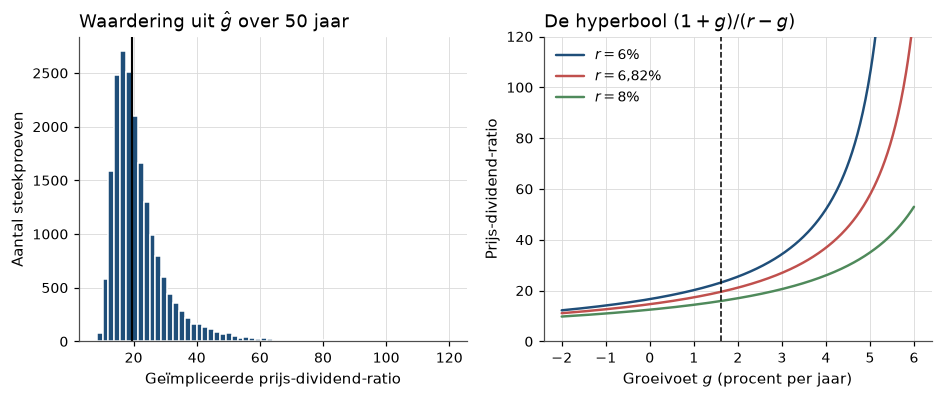

In [7]:
T_plot = 50
growth = rng.normal(g_true, sigma_g, size=(n_sim, T_plot))
g_hat = growth.mean(axis=1)
pd_hat = np.where(g_hat < r_true, (1 + g_hat) / (r_true - g_hat), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].hist(pd_hat[np.isfinite(pd_hat) & (pd_hat < 120)], bins=60, edgecolor="white")
axes[0].axvline(pd_true, color="black", lw=1.4)
axes[0].set_xlabel("Geïmpliceerde prijs-dividend-ratio")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].set_title(f"Waardering uit $\\hat g$ over {T_plot} jaar")

g_grid = np.linspace(-0.02, 0.06, 400)
for r_val, label in [(0.06, "$r = 6\\%$"), (0.0682, "$r = 6{,}82\\%$"), (0.08, "$r = 8\\%$")]:
    visible = g_grid < r_val - 0.002
    ratio = np.full_like(g_grid, np.nan)
    ratio[visible] = (1 + g_grid[visible]) / (r_val - g_grid[visible])
    axes[1].plot(g_grid * 100, ratio, lw=1.6, label=label)
axes[1].axvline(g_true * 100, color="black", lw=1.0, ls="--")
axes[1].set_ylim(0, 120)
axes[1].set_xlabel("Groeivoet $g$ (procent per jaar)")
axes[1].set_ylabel("Prijs-dividend-ratio")
axes[1].set_title("De hyperbool $ (1+g)/(r-g) $")
axes[1].legend()

plt.show()

:::{figure} #cel-williams-ddm-verdeling
:label: fig-williams-ddm-verdeling
:width: 100%

Links: de verdeling van de prijs-dividend-ratio die volgt uit een op vijftig
jaar geschatte groeivoet, met de ware waarde als verticale lijn. De verdeling is
scheef naar rechts en heeft een staart die tot in het oneindige loopt. Rechts:
waarom. De prijs-dividend-ratio is een hyperbool in $g$, met een verticale
asymptoot op $g = r$; de gestippelde lijn is de ware groeivoet. Links van de
asymptoot is de functie vlak en vergeeflijk, rechts ervan explodeert hij. Het is
dezelfde ruis in $\hat g$ die op beide plekken uitkomt.
:::

Wat deze figuur zegt over het vak: de discussie of aandelen duur zijn, is bijna
nooit een discussie over de prijs. Hij is een discussie over een klein verschil
tussen twee slecht gemeten getallen, gevoerd door mensen die een van beide voor
vast houden. Onthoud die scheefheid ook — hij komt in
[](#03-15-shiller-excess-volatility) terug als verweer tegen Shillers
variantiegrenzen.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** John Burr Williams, *The Theory of Investment Value*, Harvard
University Press 1938 {cite}`Williams1938`, in de gesloten vorm van Gordon en
Shapiro, *Capital Equipment Analysis: The Required Rate of Profit*, Management
Science 1956 {cite}`GordonShapiro1956`.

**Wat.** Er is bij Williams geen tabel om na te rekenen — het boek is een
afleiding, geen empirisch onderzoek, en Gordons eigen toets
{cite}`Gordon1959` is een cross-sectie over vier bedrijfstakken in 1951 en 1954
waarvoor de onderliggende bedrijfsgegevens niet gratis beschikbaar zijn. Wat wél
toetsbaar is, is de empirische inhoud van [](#eq-williams-ddm-pd) onder Williams'
aanname dat $r$ constant is: alle variatie in de prijs-dividend-ratio moet dan
komen uit verwachte dividendgroei, en niets uit verwachte rendementen. We
regresseren daarom de gerealiseerde reële dividendgroei over de volgende tien
jaar, en het gerealiseerde reële totaalrendement over dezelfde tien jaar, op de
log-prijs-dividend-ratio.

**Data hier.** Robert Shillers maandreeks vanaf 1871 via `hap.data.shiller()`,
teruggebracht tot decemberwaarnemingen. We gebruiken `real_price`,
`real_dividend` (het voortschrijdende twaalfmaands dividend, gedefleerd) en
`real_total_return_price` (de cum-dividend reële totaalrendementsindex). De
steekproef met een volledige tienjaarshorizon loopt van 1871 tot en met 2015,
145 overlappende waarnemingen.

**Verschil met het origineel.** Williams had geen index en geen tijdreeks; hij
rekende met de hand aan afzonderlijke bedrijven. Shillers dividendreeks is een
indexreeks en negeert inkoop van eigen aandelen, wat de gemeten $d_t$ na 1985 te
laag maakt. De regressies overlappen, dus de standaardfouten zijn Newey-West met
negen vertragingen; ze blijven optimistisch (zie de waarschuwing hieronder).

**Verwachte afwijking.** Punt schattingen zijn hier niet het punt — het teken
is het punt. Onder Williams' lezing moet de coëfficiënt in de
*dividendgroei*-regressie duidelijk positief en statistisch significant zijn, en
die in de *rendements*-regressie nul. Draait dat om — negatief en significant
voor rendementen, nul voor dividendgroei — dan is de constante-$r$-lezing van de
identiteit verworpen, en is het niet de identiteit die faalt maar de aanname over
$r$. De $R^2$ van de rendementsregressie hoort in de orde van tien procent te
liggen, niet in de orde van tachtig: ook onder de andere lezing verklaart de
prijs-dividend-ratio maar een klein deel van wat er gebeurt.
```

In [8]:
horizon = 10

pd_ratio = (annual["real_price"] / annual["real_dividend"]).rename("PD")
log_pd = np.log(pd_ratio).rename("log_pd")

future_growth = (
    np.log(annual["real_dividend"].shift(-horizon) / annual["real_dividend"]) / horizon
).rename("dividendgroei")
future_return = (
    np.log(
        annual["real_total_return_price"].shift(-horizon)
        / annual["real_total_return_price"]
    )
    / horizon
).rename("rendement")

panel = pd.concat([log_pd, future_growth, future_return], axis=1).dropna()
print(f"steekproef: {panel.index[0]:%Y} t/m {panel.index[-1]:%Y}, "
      f"{len(panel)} overlappende jaarwaarnemingen")
panel.describe().round(4)

steekproef: 1871 t/m 2015, 145 overlappende jaarwaarnemingen


,log_pd,dividendgroei,rendement
count,145.0000,145.0000,145.0000
mean,3.2059,0.0152,0.0664
std,0.4358,0.0281,0.0479
min,2.2880,-0.0671,-0.0424
25%,2.9163,0.0002,0.0373
50%,3.1311,0.0187,0.0684
75%,3.4020,0.0323,0.1021
max,4.4497,0.0840,0.1608


In [9]:
resultaten = []
for kolom, naam in [
    ("dividendgroei", "reële dividendgroei, 10 jaar vooruit"),
    ("rendement", "reëel totaalrendement, 10 jaar vooruit"),
]:
    fit = hap.newey_west(panel[kolom], panel["log_pd"], lags=horizon - 1)
    resultaten.append(
        {
            "afhankelijke variabele": naam,
            "coëfficiënt": fit.params.iloc[1],
            "standaardfout": fit.bse.iloc[1],
            "t-waarde": fit.tvalues.iloc[1],
            "R2": fit.rsquared,
        }
    )

pd.DataFrame(resultaten).set_index("afhankelijke variabele").round(4)

,coëfficiënt,standaardfout,t-waarde,R2
afhankelijke variabele,,,,
"reële dividendgroei, 10 jaar vooruit",0.0150,0.0092,1.6346,0.0543
"reëel totaalrendement, 10 jaar vooruit",-0.0375,0.0170,-2.2116,0.1165


De uitkomst is ondubbelzinnig het omgekeerde van wat Williams' lezing eist. De
prijs-dividend-ratio voorspelt de dividendgroei *niet*: de coëfficiënt is
$0{,}015$ met een $t$-waarde van $1{,}63$ en een $R^2$ van vijf procent. Het
teken wijst weliswaar de kant op die Williams nodig heeft — een hoge ratio wordt
gevolgd door iets *snellere* groei — maar de omvang is te klein om de beweging in
de ratio te dragen: één log-punt hogere ratio gaat samen met anderhalve tiende
procentpunt extra groei per jaar, cumulatief nog geen 0,15 log-punt over tien
jaar. Het toekomstige rendement voorspelt hij wel, met een
negatieve coëfficiënt van ongeveer $-0{,}04$: een prijs-dividend-ratio die één
log-punt hoger ligt (bijvoorbeeld van 20 naar 54) gaat samen met een reëel
rendement dat de volgende tien jaar bijna vier procentpunt per jaar lager is. De
$R^2$ ligt rond de twaalf procent, precies in de orde die het replicatieblok
belooft.

Onder de identiteit [](#eq-williams-ddm-pd) is er dan maar één conclusie
mogelijk: $r$ is geen constante. Wat Williams als parameter behandelde, is een
tijdreeks.

```{warning}
Deze regressies gebruiken overlappende tienjaarsperioden: 145 waarnemingen die
in werkelijkheid ongeveer veertien onafhankelijke stukken data zijn. Newey-West
met negen vertragingen corrigeert daar deels voor, maar in eindige steekproeven
onvoldoende. Bovendien is de regressor sterk persistent, wat de
coëfficiënt in eindige steekproeven omhoog vertekent (de Stambaugh-bias
{cite}`Stambaugh1999`). Behandel deze $t$-waarden als een indicatie van de
richting, niet als bewijs; de correcte behandeling staat in
[](#04-20-voorspelbaarheid).
```

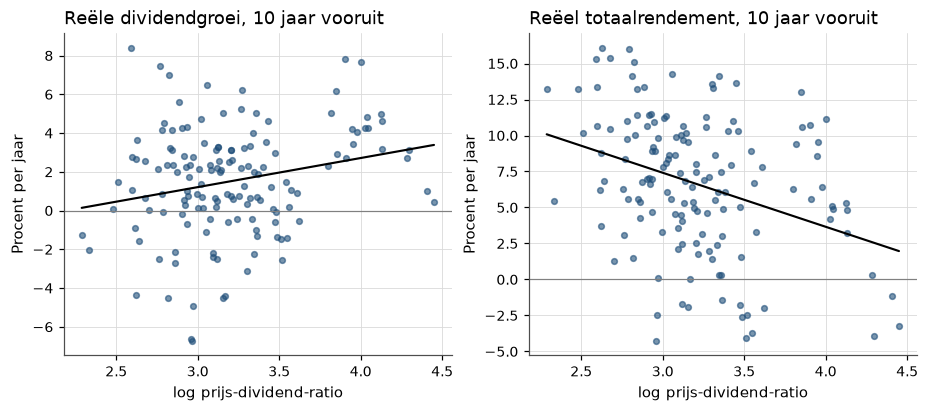

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)

for ax, kolom, titel in [
    (axes[0], "dividendgroei", "Reële dividendgroei"),
    (axes[1], "rendement", "Reëel totaalrendement"),
]:
    ax.scatter(panel["log_pd"], panel[kolom] * 100, s=14, alpha=0.6)
    b, a = np.polyfit(panel["log_pd"], panel[kolom] * 100, 1)
    grid_x = np.linspace(panel["log_pd"].min(), panel["log_pd"].max(), 50)
    ax.plot(grid_x, a + b * grid_x, color="black", lw=1.4)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("log prijs-dividend-ratio")
    ax.set_ylabel("Procent per jaar")
    ax.set_title(f"{titel}, 10 jaar vooruit")

plt.show()

:::{figure} #cel-williams-ddm-scatter
:label: fig-williams-ddm-scatter
:width: 100%

Elk punt is één decemberwaarneming tussen 1871 en 2015. Links de gerealiseerde
reële dividendgroei over de volgende tien jaar, rechts het gerealiseerde reële
totaalrendement, beide tegen de log-prijs-dividend-ratio van dat moment. De
linkerwolk heeft geen richting; de rechterwolk helt duidelijk naar beneden. Als
Williams' aanname klopte, zouden die twee panelen precies andersom moeten
liggen.
:::

Shillers eigen antwoord op dit patroon was de *cyclically adjusted price-earnings
ratio* (CAPE: de koers gedeeld door het gemiddelde van de reële winst over tien
jaar), die dezelfde gedachte toepast op winsten in plaats van dividenden en het
noemer-probleem oplost door te middelen over een conjunctuurcyclus
{cite}`Shiller2000`. CAPE is, structureel, een afstammeling van
[](#eq-williams-ddm-pd): het is een prijs gedeeld door een maatstaf van
fundamentele stroom, en het wordt om precies dezelfde reden gebruikt — omdat die
verhouding iets over toekomstige rendementen zegt.

In [11]:
cape_panel = pd.concat(
    [np.log(annual["cape"]).rename("log_cape"), future_return], axis=1
).dropna()
fit_cape = hap.newey_west(cape_panel["rendement"], cape_panel["log_cape"], lags=horizon - 1)

pd.DataFrame(
    {
        "coëfficiënt": [fit_cape.params.iloc[1]],
        "t-waarde": [fit_cape.tvalues.iloc[1]],
        "R2": [fit_cape.rsquared],
        "n": [int(fit_cape.nobs)],
    },
    index=["log CAPE → reëel rendement, 10 jaar vooruit"],
).round(4)

,coëfficiënt,t-waarde,R2,n
"log CAPE → reëel rendement, 10 jaar vooruit",-0.0592,-4.5173,0.2404,135


Op deze steekproef, die pas in 1881 begint omdat CAPE tien jaar winsthistorie
nodig heeft, is de coëfficiënt $-0{,}059$ met een $t$-waarde van $-4{,}5$ en een
$R^2$ van 0,24 — sterker dan met de prijs-dividend-ratio. Neem dat verschil niet
te serieus: CAPE is met kennis van de hele reeks als voorspeller geselecteerd,
en de standaardfouten hier lijden onder dezelfde overlap. Wat telt is dat de
richting dezelfde is, en dat Shillers maatstaf uit precies dezelfde identiteit
komt als die van Williams — alleen met een andere noemer.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Meer dan het krediet krijgt. Het dividend discount
model is geen benadering die soms werkt: onder een transversaliteitsvoorwaarde is
het een *identiteit*, en identiteiten breken niet. Het legt vast dat een prijs
alleen kan bewegen doordat verwachte uitkeringen bewegen of doordat
discontovoeten bewegen, en het maakt van elke waarderingsdiscussie een discussie
over welke van die twee het is. Het Gordon-model gaf de praktijk bovendien een
werkbare vuistregel — verwacht rendement is dividendrendement plus groei — die
in de vorm van "earnings yield plus groei" nog dagelijks wordt gebruikt, en de
PVGO-decompositie liet zien dat groei en waarde geen synoniemen zijn.

**Waar het breekt.** Niet in de identiteit maar in de aanname erboven. De
replicatie hierboven laat zien dat de prijs-dividend-ratio de tienjaarsgroei van
dividenden nauwelijks voorspelt ($R^2 \approx 5\%$, $t < 2$) en het
tienjaarsrendement wél ($R^2 \approx 12\%$, coëfficiënt ongeveer $-0{,}04$ met
$t \approx -2$). Onder [](#eq-williams-ddm-pd) betekent dat dat $r$ beweegt. Het
enige symbool dat Williams als gegeven aannam, is het symbool dat het meeste
werk doet — en over de vraag waar die beweging vandaan komt, gaat de rest van
deze reeks.

**Risico of vergissing?** Twee lezingen van dezelfde tabel, allebei consistent
met de data. De Chicago-lezing: $r$ is de vergoeding die beleggers vragen om
aandelenrisico te dragen, en die vergoeding is hoog wanneer mensen arm en bang
zijn en laag wanneer ze rijk zijn. Aandelen zijn goedkoop in een depressie omdat
niemand het risico dán wil dragen; wie het toch draagt, wordt daarvoor betaald,
en de voorspelbaarheid van rendementen is dan geen anomalie maar precies wat een
goed werkende markt zou doen. De Yale-lezing: mensen extrapoleren de laatste
jaren, betalen te veel na goede jaren en te weinig na slechte, en de
voorspelbaarheid is de langzame correctie van hun vergissing. De data in de
figuur hierboven scheidt de twee niet, en kán dat ook niet: beide lezingen
voorspellen precies dezelfde negatieve helling. Ze verschillen pas zodra u een
theorie over $r$ oplegt — en dat is de vraag waar het vak in 2013 nog steeds
niet uit was, toen Fama en Shiller samen de Nobelprijs kregen (zie
[](#05-33-fama-vs-shiller)).

**Wat er daarna kwam.** Williams had geen theorie van $r$, maar wel het inzicht
dat u er een nodig hebt; de eerste die de vraag verplaatste van "wat is dit
aandeel waard" naar "welke portefeuille wilt u houden, en welk risico telt
daarbij" was Markowitz — zie [](#01-04-markowitz).

Noteer tot slot de epistemische status, want die verschuift in deze lecture. Bij
Bachelier ging het om een *feit* (koersen bewegen als een random walk) dat op een
verklaring wachtte. Bij Williams gaat het om een *identiteit*: iets wat waar is
zonder dat het iets uitsluit, en dat pas inhoud krijgt zodra u er een aanname
aan toevoegt. De aanname die Williams koos — constante $r$ — is toetsbaar en
verworpen. Elk model in de rest van deze reeks is te lezen als een ander,
scherper antwoord op dezelfde openstaande vraag: waar komt $r$ vandaan?

## Oefeningen

:::{exercise}
:label: ex-williams-ddm-1

**De bel die het model toestaat.** Neem $r = 8\%$, $d_0 = 2{,}00$ en constante
dividendgroei $g = 3\%$.

1. Bereken de fundamentele waarde $p^{f}_0$ en de fundamentele
   prijs-dividend-ratio.
2. Laat zien dat $p_t = p^{f}_t + b_t$ met $\E_t[b_{t+1}] = (1+r) b_t$ voldoet
   aan $p_t = \E_t[d_{t+1}+p_{t+1}]/(1+r)$.
3. Stel dat de werkelijke prijs op $t=0$ gelijk is aan $p_0 = p^{f}_0 + 10$.
   Bereken de verwachte prijs-dividend-ratio na 10, 25 en 50 jaar in dit
   belscenario, aannemende dat de bel exact zijn verwachte pad volgt. Op welk
   moment is meer dan de helft van de prijs bel?
:::

:::{solution} ex-williams-ddm-1
:class: dropdown

**(1)** $p^f_0 = d_0(1+g)/(r-g) = 2{,}00 \times 1{,}03/0{,}05 = 41{,}20$, dus
$\mathrm{PD} = 20{,}6$.

**(2)** Vul in: $\E_t[d_{t+1} + p^f_{t+1} + b_{t+1}]/(1+r)
= \left(\E_t[d_{t+1}+p^f_{t+1}] + (1+r)b_t\right)/(1+r) = p^f_t + b_t$, waarbij
de eerste term $p^f_t$ geeft omdat $p^f$ per constructie aan de vergelijking
voldoet. De bel voegt dus niets toe aan de restrictie: hij is een tweede,
even geldige oplossing van dezelfde differentievergelijking.

**(3)**

In [12]:
r_ex, d0_ex, g_ex, b0 = 0.08, 2.00, 0.03, 10.0

t_grid = np.array([0, 10, 25, 50])
d_t = d0_ex * (1 + g_ex) ** t_grid
p_f = d_t * (1 + g_ex) / (r_ex - g_ex)
b_t = b0 * (1 + r_ex) ** t_grid

bel = pd.DataFrame(
    {
        "jaar": t_grid,
        "fundamenteel": p_f,
        "bel": b_t,
        "prijs": p_f + b_t,
        "PD-ratio": (p_f + b_t) / d_t,
        "aandeel bel": b_t / (p_f + b_t),
    }
).set_index("jaar").round(3)

kruispunt = next(t for t in range(200)
                 if b0 * (1 + r_ex) ** t > d0_ex * (1 + g_ex) ** (t + 1) / (r_ex - g_ex))
print(f"de bel is meer dan de helft van de prijs vanaf jaar {kruispunt}")
bel

de bel is meer dan de helft van de prijs vanaf jaar 30


,fundamenteel,bel,prijs,PD-ratio,aandeel bel
jaar,,,,,
0,41.200,10.000,51.200,25.600,0.195
10,55.369,21.589,76.959,28.632,0.281
25,86.264,68.485,154.748,36.954,0.443
50,180.617,469.016,649.633,74.093,0.722


De bel groeit met 8% per jaar, het fundament met 3%, dus het aandeel van de bel
loopt onvermijdelijk naar één. Wat de oefening over het hoofdargument leert: de
transversaliteitsvoorwaarde is geen technische bijzaak maar precies de aanname
die verbiedt dat de prijs-dividend-ratio voor altijd blijft stijgen — en dat is
een aanname over gedrag, niet over wiskunde.
:::

:::{exercise}
:label: ex-williams-ddm-2

**Groei die waarde vernietigt.** Een bedrijf verwacht volgend jaar een winst per
aandeel van $e_1 = 5{,}00$. De discontovoet is $r = 9\%$.

1. Bereken de prijs en de PVGO voor $\mathrm{ROE} \in \{6\%, 9\%, 12\%\}$ bij een
   inhoudingspercentage $b = 0{,}5$.
2. Bepaal voor elk van de drie gevallen het inhoudingspercentage $b$ dat de
   prijs maximaliseert, door $b$ over een fijn raster te laten lopen.
3. Verklaar in één zin waarom het antwoord op (2) niet van $e_1$ afhangt.
:::

:::{solution} ex-williams-ddm-2
:class: dropdown

In [13]:
e1_ex, r_ex2 = 5.00, 0.09
b_grid = np.linspace(0.0, 0.95, 191)

rows_pvgo = []
for roe in (0.06, 0.09, 0.12):
    price_half = (1 - 0.5) * e1_ex / (r_ex2 - 0.5 * roe)
    feasible = b_grid * roe < r_ex2 - 1e-9
    prices = np.full_like(b_grid, np.nan)
    prices[feasible] = (1 - b_grid[feasible]) * e1_ex / (r_ex2 - b_grid[feasible] * roe)
    rows_pvgo.append(
        {
            "ROE": roe,
            "prijs bij b=0.5": price_half,
            "PVGO bij b=0.5": price_half - e1_ex / r_ex2,
            "optimale b": b_grid[np.nanargmax(prices)],
            "prijs bij optimale b": np.nanmax(prices),
        }
    )

pd.DataFrame(rows_pvgo).set_index("ROE").round(4)

,prijs bij b=0.5,PVGO bij b=0.5,optimale b,prijs bij optimale b
ROE,,,,
0.06,41.6667,-13.8889,0.000,55.5556
0.09,55.5556,0.0000,0.940,55.5556
0.12,83.3333,27.7778,0.745,2125.0000


Bij $\mathrm{ROE} = 6\% < r$ is de PVGO $-13{,}89$ en is de optimale $b$ gelijk
aan nul: alles uitkeren. Bij $\mathrm{ROE} = 9\% = r$ maakt $b$ niets uit — de
prijs is $e_1/r = 55{,}56$ voor élk inhoudingspercentage, zodat het raster een
willekeurig punt als "optimum" aanwijst; dat is precies de irrelevantiestelling
van Miller en Modigliani {cite}`MillerModigliani1961`. Bij
$\mathrm{ROE} = 12\% > r$ loopt de optimale $b$ naar de asymptoot
$b = r/\mathrm{ROE} = 0{,}75$ en explodeert de prijs, want het model kent geen
afnemende meeropbrengsten: elke ingehouden euro verdient eeuwig 12% terwijl u
9% eist.

**(3)** De prijs is homogeen van graad één in $e_1$: $e_1$ staat als
vermenigvuldigende factor voor de hele uitdrukking, dus het argument dat de
uitdrukking maximaliseert verandert er niet door. Wat de oefening over het
hoofdargument leert: "groei" is in dit model geen aparte waardebron, maar een
herverpakking van $\mathrm{ROE} - r$.
:::

:::{exercise}
:label: ex-williams-ddm-3

**De replicatie op een andere steekproef.** Herhaal de twee regressies uit de
replicatie op de naoorlogse steekproef (waarnemingen vanaf december 1945) en op
een horizon van vijf jaar in plaats van tien. Rapporteer coëfficiënt,
$t$-waarde en $R^2$ voor beide afhankelijke variabelen, en beantwoord: verandert
de *conclusie* over welke van de twee kanalen beweegt?
:::

:::{solution} ex-williams-ddm-3
:class: dropdown

In [14]:
def horizon_panel(frame, h, start=None):
    """Overlapping h-year forward growth and return, against log PD."""
    sub = frame if start is None else frame.loc[start:]
    lpd = np.log(sub["real_price"] / sub["real_dividend"]).rename("log_pd")
    gro = (np.log(sub["real_dividend"].shift(-h) / sub["real_dividend"]) / h).rename(
        "dividendgroei"
    )
    ret = (
        np.log(sub["real_total_return_price"].shift(-h) / sub["real_total_return_price"])
        / h
    ).rename("rendement")
    return pd.concat([lpd, gro, ret], axis=1).dropna()


rows_ex = []
for label, h, start in [
    ("1871–, h=10", 10, None),
    ("1945–, h=10", 10, "1945"),
    ("1871–, h=5", 5, None),
    ("1945–, h=5", 5, "1945"),
]:
    frame = horizon_panel(annual, h, start)
    for kolom in ("dividendgroei", "rendement"):
        fit = hap.newey_west(frame[kolom], frame["log_pd"], lags=h - 1)
        rows_ex.append(
            {
                "steekproef": label,
                "variabele": kolom,
                "coëfficiënt": fit.params.iloc[1],
                "t-waarde": fit.tvalues.iloc[1],
                "R2": fit.rsquared,
                "n": int(fit.nobs),
            }
        )

pd.DataFrame(rows_ex).set_index(["steekproef", "variabele"]).round(4)

coëfficiënt  t-waarde      R2    n
steekproef  variabele                                        
1871–, h=10 dividendgroei       0.0150    1.6346  0.0543  145
            rendement          -0.0375   -2.2116  0.1165  145
1945–, h=10 dividendgroei       0.0102    0.9791  0.0401   71
            rendement          -0.0634   -3.4964  0.2685   71
1871–, h=5  dividendgroei       0.0263    2.0237  0.0583  150
            rendement          -0.0446   -2.2794  0.0780  150
1945–, h=5  dividendgroei       0.0062    0.4585  0.0065   76
            rendement          -0.0679   -3.0778  0.1791   76

De rendementscoëfficiënt is in alle vier de varianten negatief, en naoorlogs
zelfs uitgesprokener ($-0{,}063$ met $t = -3{,}50$ op tien jaar). De
dividendgroeicoëfficiënt is overal klein; alleen over de volle steekproef op
vijf jaar haalt hij net significantie ($0{,}026$, $t = 2{,}02$), en dat is dan
nog steeds veel te weinig om het werk te doen: cumulatief over vijf jaar
reageert de dividendgroei met $5 \times 0{,}026 \approx 0{,}13$ log-punt op één
log-punt prijs-dividend-ratio, tegen $5 \times 0{,}045 \approx 0{,}22$ voor het
rendement. De conclusie verandert dus niet, maar let op hoezeer de $t$-waarden
schommelen: met 71 naoorlogse waarnemingen op een horizon van tien jaar zijn er
nog geen acht onafhankelijke perioden. Wat de oefening over het hoofdargument
leert: de richting van het resultaat is robuust, de sterkte ervan is dat niet,
en dat is precies het 2%-motief in de context van voorspelbaarheid.
:::